# Watershed Segmentation

Watershed treats an image (or its gradient) as a topographic surface and floods it from a set of markers. 
Where two floods would merge, a boundary ("dam") is placed instead. This notebook covers two classic 
watershed use cases:
1. **Separating touching objects** via the distance transform
2. **The over-segmentation problem** and how marker control fixes it

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
from skimage import data
from skimage.draw import disk
from skimage.filters import sobel
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from skimage.color import label2rgb

## 1. Why Watershed? — Touching Objects

Threshold or region-growing on a binary mask of touching/overlapping objects merges them into a single blob, 
since there's no pixel-level cue at the point where two objects meet.

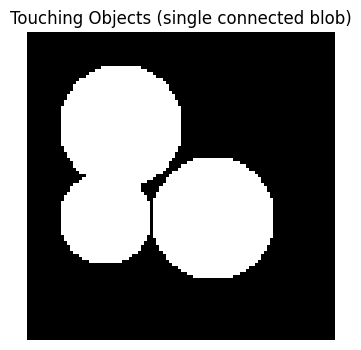

In [2]:
# Synthetic binary mask with three overlapping circular blobs
image = np.zeros((100, 100), dtype=bool)
image[disk((30, 30), 20, shape=image.shape)] = True
image[disk((60, 60), 20, shape=image.shape)] = True
image[disk((60, 25), 15, shape=image.shape)] = True

plt.figure(figsize=(4, 4))
plt.imshow(image, cmap='gray')
plt.title('Touching Objects (single connected blob)')
plt.axis('off')
plt.show()

## 2. Marker-Controlled Watershed via Distance Transform

For round touching objects, the **distance transform** (distance of each foreground pixel to the nearest 
background pixel) peaks at each object's center. Those peaks become markers, and watershed floods the 
*negative* distance transform (so basins grow outward from each peak, and a dam forms where two objects touch).

Found 3 markers (object centers)


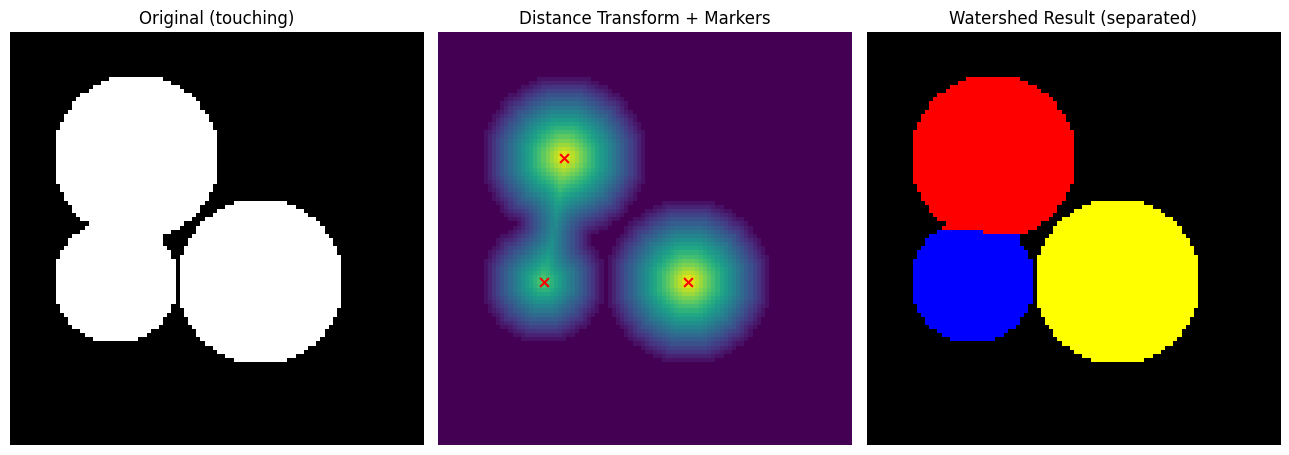

In [4]:
distance = ndi.distance_transform_edt(image)

# Local maxima of the distance transform = object centers = markers
coords = peak_local_max(distance, footprint=np.ones((15, 15)), labels=image)
mask = np.zeros(distance.shape, dtype=bool)
mask[tuple(coords.T)] = True
markers, num_markers = ndi.label(mask)
print(f'Found {num_markers} markers (object centers)')

labels = watershed(-distance, markers, mask=image)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original (touching)')

axes[1].imshow(distance, cmap='viridis')
axes[1].scatter(coords[:, 1], coords[:, 0], c='red', s=40, marker='x')
axes[1].set_title('Distance Transform + Markers')

axes[2].imshow(label2rgb(labels, bg_label=0))
axes[2].set_title('Watershed Result (separated)')

for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

## 3. The Over-Segmentation Problem

Now apply watershed the naive way, directly on the gradient of a real (noisy/textured) grayscale image, 
using *every* very-low-gradient pixel as a marker. Real images have far more spurious local minima than 
true object boundaries, so this floods from hundreds of unwanted seeds.

Naive marker count: 2951
Naive result: 2951 regions


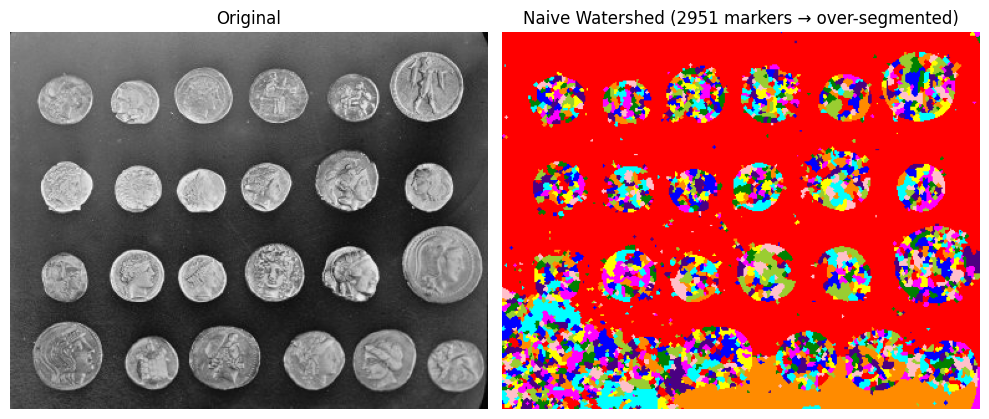

In [5]:
coins = data.coins()
elevation_map = sobel(coins)

# Naive: treat every near-flat (very low gradient) pixel as its own basin seed
naive_markers, n_naive = ndi.label(elevation_map < 0.02)
print(f'Naive marker count: {n_naive}')

naive_seg = watershed(elevation_map, naive_markers)
print(f'Naive result: {len(np.unique(naive_seg))} regions')

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(coins, cmap='gray')
axes[0].set_title('Original')
axes[1].imshow(label2rgb(naive_seg, bg_label=0))
axes[1].set_title(f'Naive Watershed ({n_naive} markers → over-segmented)')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

## 4. Fixing It: Marker-Controlled Watershed

Instead of letting every gradient dip become a seed, we hand-pick just two markers using simple intensity 
cues: clearly dark pixels (background) and clearly bright pixels (coin interiors). Watershed then floods 
outward from only these two labels along the same gradient surface, landing exactly on the coin edges.

Controlled result: 2 regions


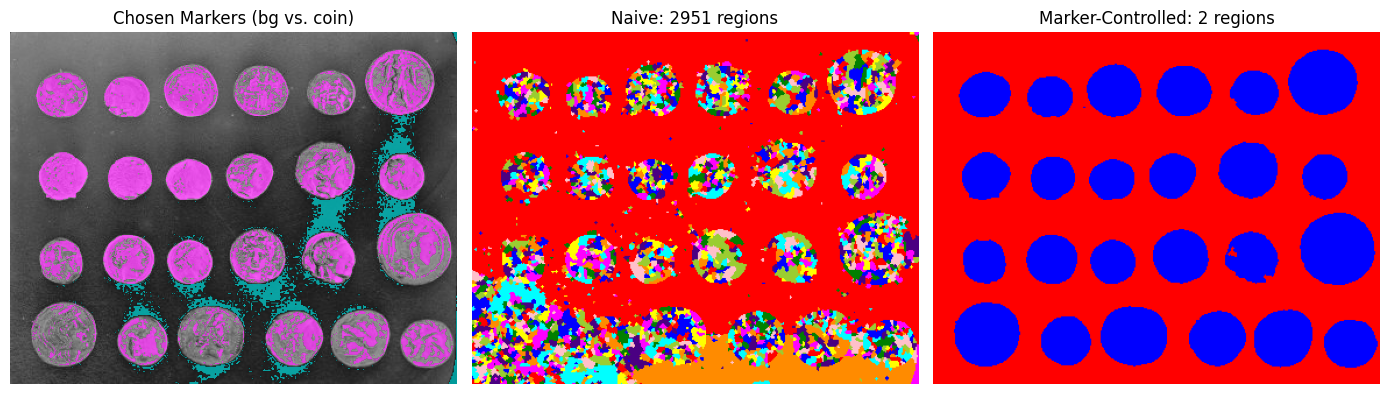

In [6]:
markers = np.zeros_like(coins, dtype=int)
markers[coins < 30] = 1   # confident background
markers[coins > 150] = 2  # confident coin interior

controlled_seg = watershed(elevation_map, markers)
print(f'Controlled result: {len(np.unique(controlled_seg))} regions')

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
axes[0].imshow(coins, cmap='gray')
marker_display = np.ma.masked_where(markers == 0, markers)
axes[0].imshow(marker_display, cmap='cool', alpha=0.6)
axes[0].set_title('Chosen Markers (bg vs. coin)')

axes[1].imshow(label2rgb(naive_seg, bg_label=0))
axes[1].set_title(f'Naive: {n_naive} regions')

axes[2].imshow(label2rgb(controlled_seg, bg_label=0))
axes[2].set_title('Marker-Controlled: 2 regions')

for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

**Notes**
- The naive run floods from thousands of texture-driven local minima — every tiny gradient dip becomes its own basin.
- The controlled run floods from just 2 markers and lands cleanly on the true coin/background boundaries, because the *dam-building* mechanism still finds the real edges — it's the *seeding* that needed constraining, not the flooding rule itself.
- For separating individual touching objects (not just foreground/background), the distance-transform approach in Section 2 is the standard recipe.
- Try changing the `footprint` size in `peak_local_max` or the intensity cutoffs (`< 30`, `> 150`) and re-running to see how marker choice changes the result.